In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import sys
sys.path.append("..")
from src.data_splitting import *

In [2]:
df = load_dataset("../datasets/processed/dataset_hybrid.csv")
df.drop(columns=['output_pv', 'output_wind'], inplace=True)
train, eval, test = split_dataset(df, train_ratio = 0.70, eval_ratio = 0.15)
print_split_summary(train, eval, test)
save_split_dataset(train, eval, test, "../datasets/processed/")

Total: 8753
Train: 6127 (70.00%)
eValidation: 1313 (15.00%)
Test: 1313 (15.00%)


In [3]:
train_combine, eval_dummy, test_dummy = split_dataset(df, train_ratio = 0.85, eval_ratio = 0.0)
print_split_summary(train_combine, eval_dummy, test_dummy)
train_combine.to_csv("../datasets/processed/train_combine.csv", index=False)

Total: 8753
Train: 7440 (85.00%)
eValidation: 0 (0.00%)
Test: 1313 (15.00%)


<Figure size 640x480 with 0 Axes>

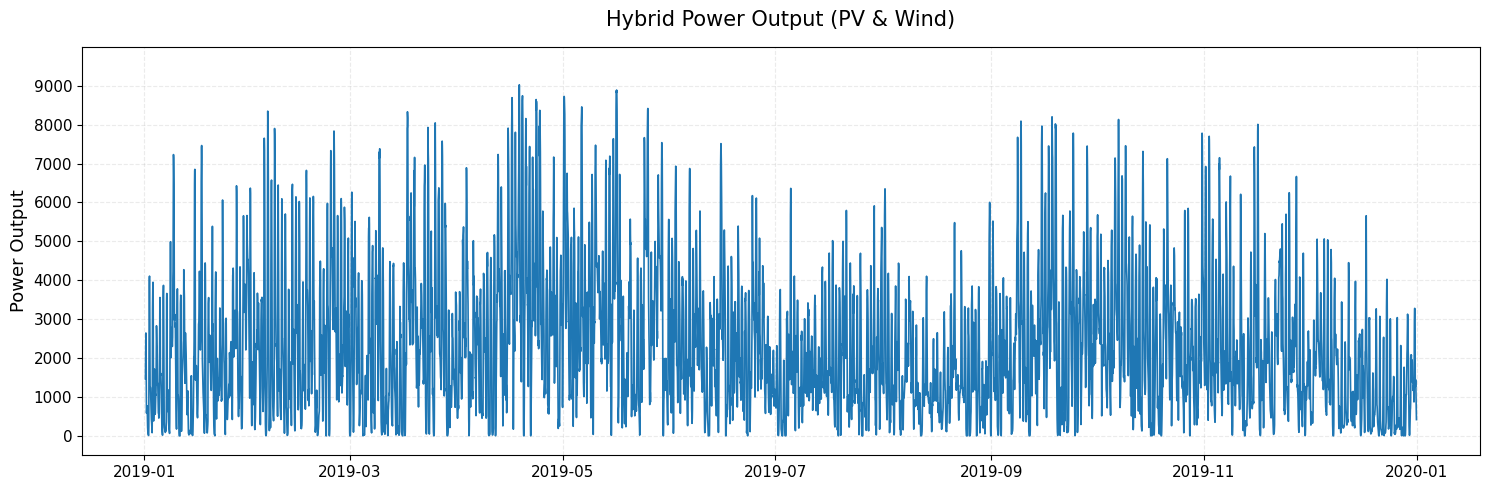

In [4]:
plt.close('all') 
plt.clf()

plt.figure(figsize=(15, 5))

plt.plot(df['timestamp'], df['output_hybrid'], linewidth=1.2)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=0, fontsize=11)
plt.yticks(np.arange(0, 10000, 1000), fontsize=11)
plt.ylim(-500, 10000)

plt.ylabel('Power Output', fontsize=13)
plt.title('Hybrid Power Output (PV & Wind)', fontsize=15, pad=15)
plt.grid(True, linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()

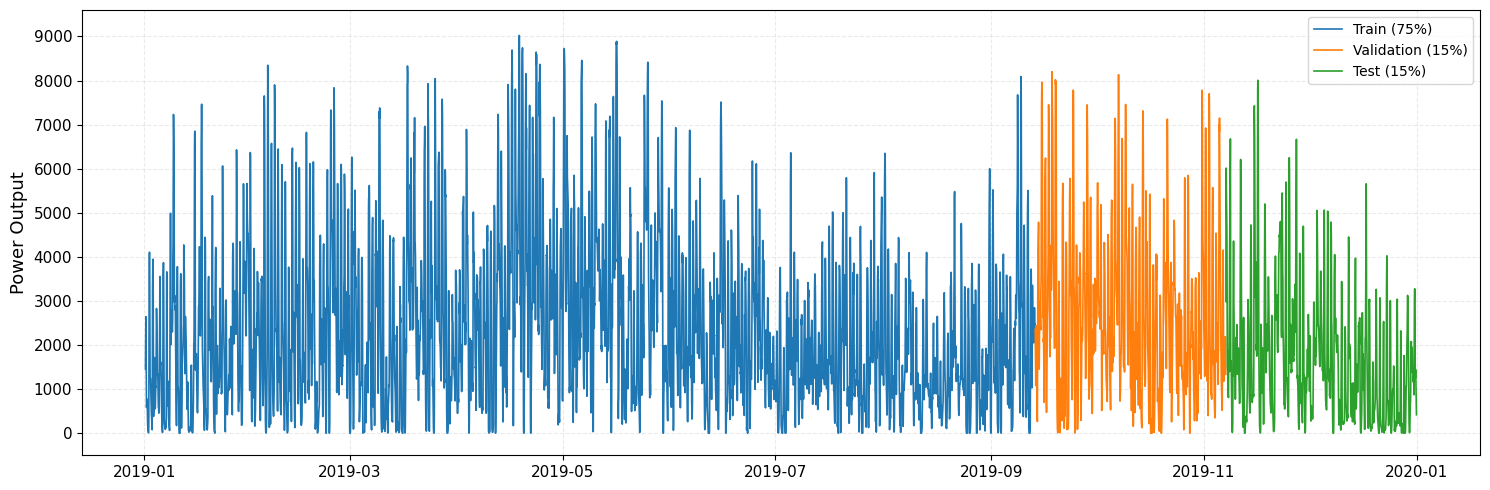

In [5]:
plt.figure(figsize=(15, 5))

plt.plot(train['timestamp'], train['output_hybrid'], label='Train (75%)', linewidth=1.2)
plt.plot(eval['timestamp'], eval['output_hybrid'], label='Validation (15%)', linewidth=1.2)
plt.plot(test['timestamp'], test['output_hybrid'], label='Test (15%)', linewidth=1.2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=0, fontsize=11)

plt.yticks(
    np.arange(0, 10000, 1000),
    fontsize=11
)

plt.ylim(-500, 9600)

plt.ylabel('Power Output', fontsize=13)
# plt.title('Hybrid Power Output - Train/Validation/Test Split', fontsize=15, pad=15)

plt.grid(True, linestyle='--', alpha=0.25)
plt.legend()

plt.tight_layout()
plt.savefig('../result/images_paper/Figure3.png', dpi=300, bbox_inches='tight')
plt.show()